In [1]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [ ]:
# Inserisco qui il link dell'API dell'ISTAT
url_api = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"

headers = {'Accept': 'text/csv'}

# Faccio la richiesta al server per scaricare i dati
print("Download dei dati in corso...")
risposta = requests.get(url_api, headers=headers)

# Controllo che il download sia andato a buon fine (il codice 200 significa OK)
if risposta.status_code == 200:
    print("Download completato! Salvo il file CSV...")
    
    # Salvo il contenuto in CSV
    with open("incidenti_istat.csv", 'wb') as file:
        file.write(risposta.content)
        
    # Carico i dati in Pandas per poterli analizzare
    df_incidenti = pd.read_csv("incidenti_istat.csv")
    
    # Guardo le prime 5 righe per assicurarmi che sia tutto a posto
    display(df_incidenti.head())

else:
    print("Errore durante il download. Codice:", risposta.status_code)

In [2]:
# Ricarico i dati del CSV
df_incidenti = pd.read_csv("incidenti_istat.csv")

display(df_incidenti.info())

<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          573552 non-null  str    
 1   FREQ              573552 non-null  str    
 2   REF_AREA          573552 non-null  int64  
 3   DATA_TYPE         573552 non-null  str    
 4   RESULT            573552 non-null  str    
 5   TIME_PERIOD       573552 non-null  int64  
 6   OBS_VALUE         573552 non-null  int64  
 7   OBS_STATUS        0 non-null       float64
 8   NOTE_DS           0 non-null       float64
 9   NOTE_REF_AREA     0 non-null       float64
 10  NOTE_DATA_TYPE    0 non-null       float64
 11  NOTE_RESULT       0 non-null       float64
 12  NOTE_TIME_PERIOD  0 non-null       float64
 13  BASE_PER          0 non-null       float64
 14  UNIT_MEAS         0 non-null       float64
 15  UNIT_MULT         0 non-null       float64
dtypes: float64(9), int64(3), str(4)

None

In [3]:
# Pulizia colonne
colonne_da_tenere = ['REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE']
df_pulito = df_incidenti[colonne_da_tenere].copy()

# Esplorazione dei valori
print("Valori unici in DATA_TYPE:", df_pulito['DATA_TYPE'].unique())
print("Valori unici in RESULT:", df_pulito['RESULT'].unique())

Valori unici in DATA_TYPE: <StringArray>
['KILLINJ', 'ROADACC']
Length: 2, dtype: str
Valori unici in RESULT: <StringArray>
['F', 'M', '9']
Length: 3, dtype: str


In [4]:
# Filtro e tengo solo gli incidenti stradali ('ROADACC') e il totale ('9')
df_filtrato = df_pulito[(df_pulito['DATA_TYPE'] == 'ROADACC') & (df_pulito['RESULT'] == '9')].copy()

# Rimuovo le colonne che ora contengono valori tutti uguali
df_filtrato.drop(columns=['DATA_TYPE', 'RESULT'], inplace=True)

# Rinomino le colonne per renderle più chiare
df_filtrato.rename(columns={
    'REF_AREA': 'codice_comune',
    'TIME_PERIOD': 'anno',
    'OBS_VALUE': 'totale_incidenti'
}, inplace=True)

# Salvo il dataset pulito in un nuovo file CSV
df_filtrato.to_csv("incidenti_puliti.csv", index=False)

print("Pulizia completata! Ecco il dataset pronto per l'analisi:")
display(df_filtrato.head())

Pulizia completata! Ecco il dataset pronto per l'analisi:


,codice_comune,anno,totale_incidenti
48,1001,2001,5
49,1001,2002,5
50,1001,2003,4
51,1001,2004,9
52,1001,2005,2


In [5]:
# preparo l'importazione dei csv situas
lista = []
percorso_file = 'download_situas'

print("Inizio caricamento dei file multipli dalla cartella...")

# ciclo for per leggere tutti i file nella cartella
for i in os.listdir(percorso_file):
      if i.endswith('.csv'):
        # uso os.path.join per evitare errori di slash
        percorso_completo = os.path.join(percorso_file, i)
        
        # leggo il singolo file
        df_tmp = pd.read_csv(percorso_completo, sep=';', keep_default_na=False)
        
        # isolo solo le colonne che mi interessano
        df_tmp = df_tmp[['Codice Comune (numerico)', 'Comune', 'Superficie (Kmq)', 'Popolazione residente']]
        
        # Aggiungo il pezzettino alla lista
        lista.append(df_tmp)

# concateno tutti i piccoli dataframe in un unico grande blocco
df_popolazione = pd.concat(lista)

# rimuovo i comuni doppi tenendone solo uno per codice
df_popolazione = df_popolazione.drop_duplicates(subset=['Codice Comune (numerico)'])

# stampo il risultato
print("Caricamento e rimozione duplicati completati")
print(f"Il dataset ISTAT ora ha {len(df_popolazione)} righe.")
display(df_popolazione.head())

Inizio caricamento dei file multipli dalla cartella...
Caricamento e rimozione duplicati completati
Il dataset ISTAT ora ha 8578 righe.


,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente
0,1001,Agliè,"13,1462",2557
1,1002,Airasca,"15,7393",3543
2,1003,Ala di Stura,"46,3315",480
3,1004,Albiano d'Ivrea,"11,7315",1687
4,1005,Alice Superiore,"7,3796",619


In [6]:
# funzione per pulire e trasformare la superficie in numero
def pulisci_superficie(valore):
    valore = str(valore).replace(',', '.')
    parti = valore.split('.')
    if len(parti) > 2:
        valore = "".join(parti[:-1]) + "." + parti[-1]
    return float(valore)

# applico la pulizia
df_popolazione['Superficie (Kmq)'] = df_popolazione['Superficie (Kmq)'].apply(pulisci_superficie)

# unisco i dataframe usando 'codice_comune' e 'Codice Comune (numerico)' (dal file ISTAT)
df_finale = pd.merge(df_filtrato, df_popolazione, left_on='codice_comune', right_on='Codice Comune (numerico)', how='left')

# rimuovo la colonna duplicata
df_finale = df_finale.drop(columns=['Codice Comune (numerico)'])

# calcolo gli indicatori
df_finale['incidenti_pro_capite'] = (df_finale['totale_incidenti'] / df_finale['Popolazione residente']) * 1000
df_finale['incidenti_per_kmq'] = df_finale['totale_incidenti'] / df_finale['Superficie (Kmq)']

# risultato finale
print("Dataset finale creato con successo!")
display(df_finale.head())
df_finale.to_csv("dataset_finale.csv", index=False)

Dataset finale creato con successo!


,codice_comune,anno,totale_incidenti,Comune,Superficie (Kmq),Popolazione residente,incidenti_pro_capite,incidenti_per_kmq
0,1001,2001,5,Agliè,13.1462,2557,1.955417,0.380338
1,1001,2002,5,Agliè,13.1462,2557,1.955417,0.380338
2,1001,2003,4,Agliè,13.1462,2557,1.564333,0.304270
3,1001,2004,9,Agliè,13.1462,2557,3.519750,0.684608
4,1001,2005,2,Agliè,13.1462,2557,0.782167,0.152135


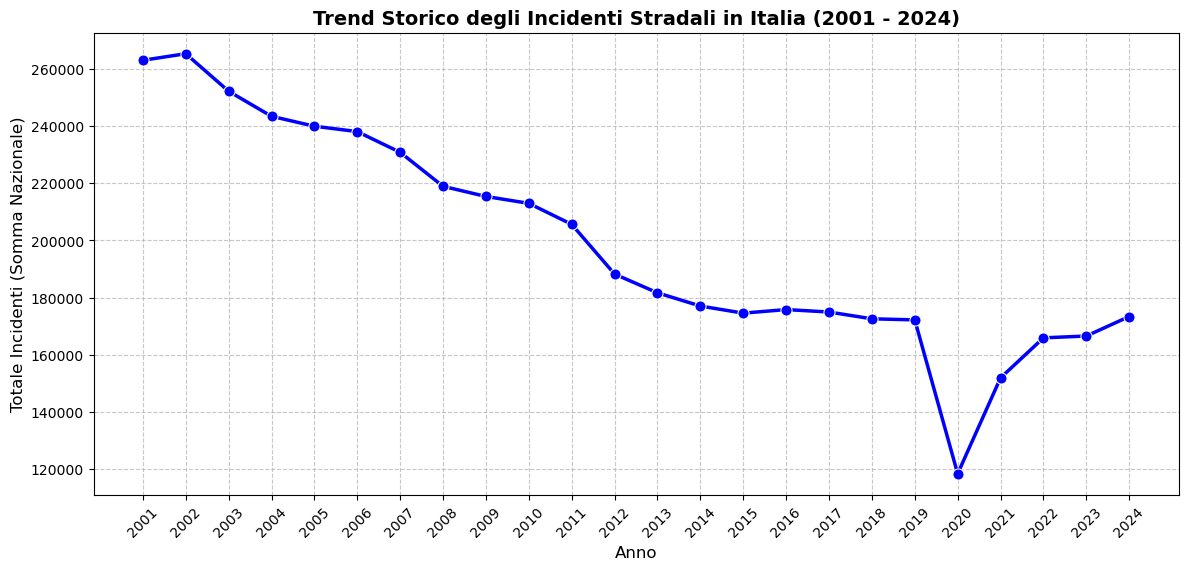

In [7]:
# Calcolo il totale degli incidenti in Italia per ogni anno
trend_annuale = df_finale.groupby('anno')['totale_incidenti'].sum().reset_index()

# Creo il trend plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_annuale, x='anno', y='totale_incidenti', 
             marker='o', color='b', linewidth=2.5, markersize=8)

# Aggiungo titoli e etichette
plt.title('Trend Storico degli Incidenti Stradali in Italia (2001 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Totale Incidenti (Somma Nazionale)', fontsize=12)

# Imposto l'asse X per mostrare tutti gli anni chiaramente
plt.xticks(trend_annuale['anno'], rotation=45)

# Aggiungo una griglia per facilitare la lettura
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

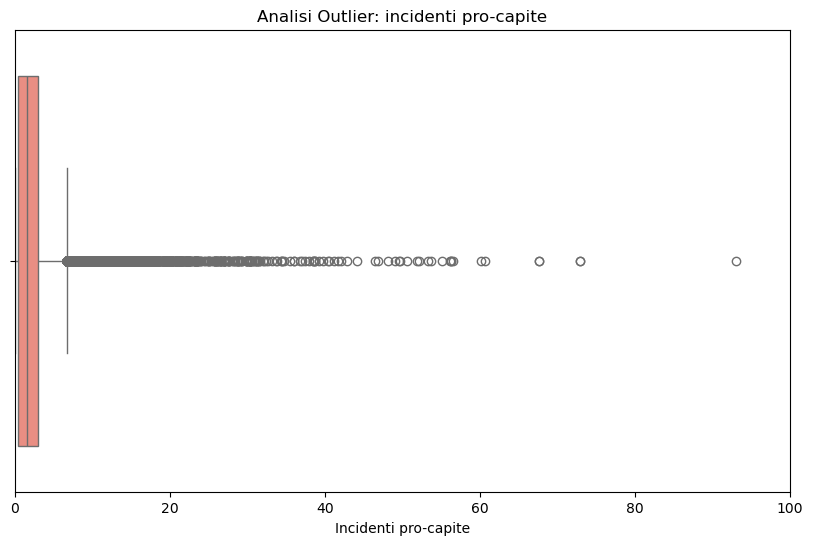

In [8]:
# Boxplot: Analisi degli outlier
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_finale['incidenti_pro_capite'], color='salmon')
plt.xlim(0, 100)
plt.title('Analisi Outlier: incidenti pro-capite')
plt.xlabel('Incidenti pro-capite')
plt.show()

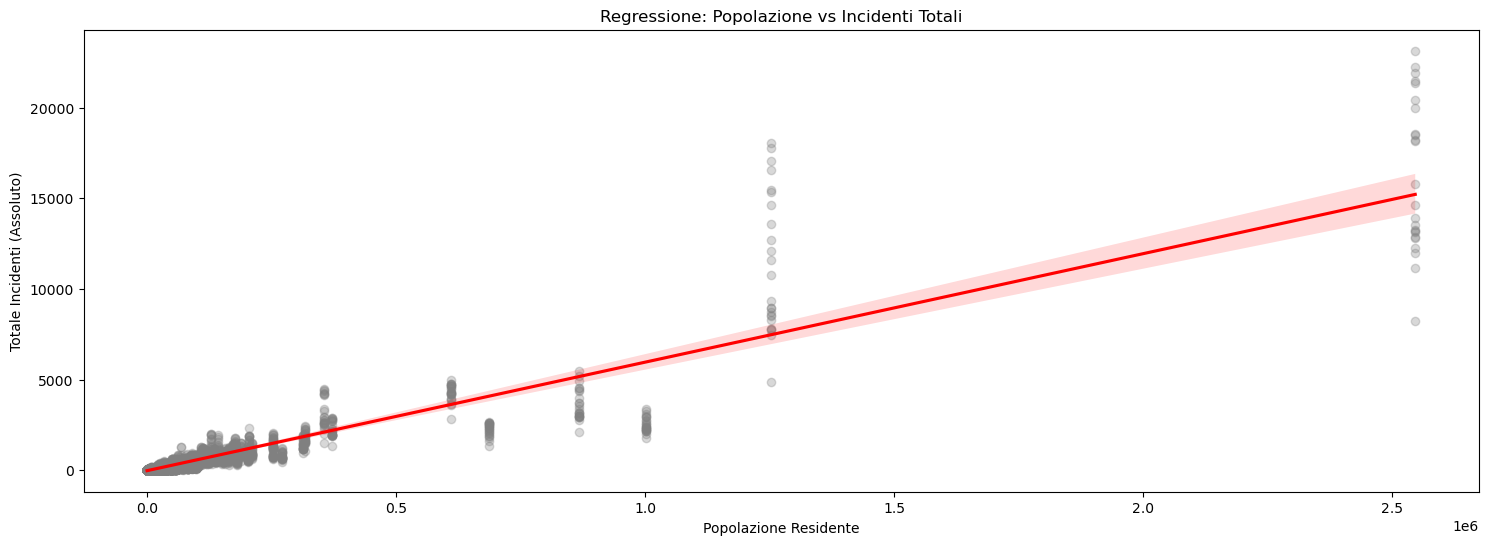

In [18]:
# Scatterplot con linea di regressione
plt.figure(figsize=(18, 6))
sns.regplot(data=df_finale, x='Popolazione residente', y='totale_incidenti', 
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Regressione: Popolazione vs Incidenti Totali')
plt.xlabel('Popolazione Residente')
plt.ylabel('Totale Incidenti (Assoluto)')
plt.show()

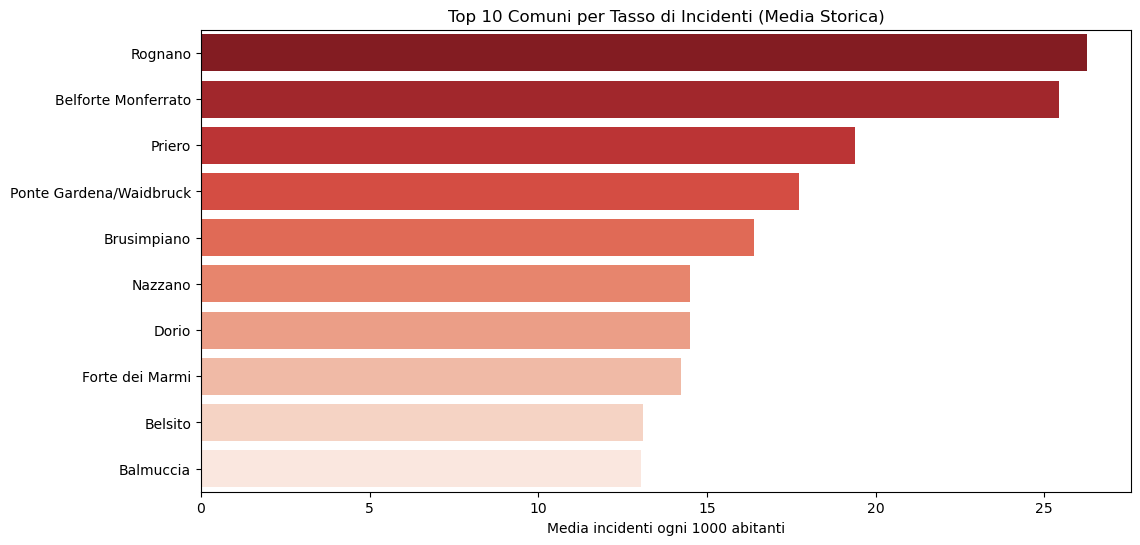

In [10]:
# Calcolo classifica dei comuni più critici
top_10 = df_finale.groupby('Comune')['incidenti_pro_capite'].mean().reset_index()
top_10 = top_10.sort_values(by='incidenti_pro_capite', ascending=False).head(10)

# Grafico a barre
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='incidenti_pro_capite', y='Comune', hue='Comune', palette='Reds_r', legend=False)
plt.title('Top 10 Comuni per Tasso di Incidenti (Media Storica)')
plt.xlabel('Media incidenti ogni 1000 abitanti')
plt.ylabel('')
plt.show()

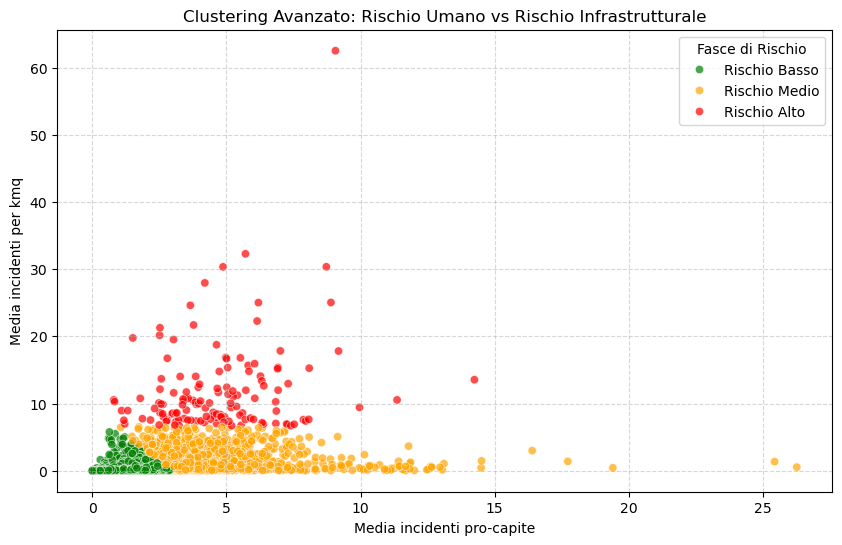

In [25]:
# Importiamo la libreria standard per il Machine Learning (K-Means)
from sklearn.cluster import KMeans

# 1. Prepariamo i dati: calcoliamo la media storica per ogni comune
df_cluster = df_finale.groupby('Comune').agg({
    'incidenti_pro_capite': 'mean',
    'incidenti_per_kmq': 'mean'
}).reset_index()

# 2. Inizializziamo l'algoritmo K-Means chiedendo di creare 3 gruppi
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 3. Facciamo studiare i dati all'algoritmo usando entrambe le metriche di rischio
df_cluster['Cluster'] = kmeans.fit_predict(df_cluster[['incidenti_pro_capite', 'incidenti_per_kmq']])

mappa_rischio = {
    1: 'Rischio Basso',
    2: 'Rischio Medio',
    0: 'Rischio Alto'
}
df_cluster['Livello di Rischio'] = df_cluster['Cluster'].map(mappa_rischio)

colori_semaforo = {
    'Rischio Basso': 'green',
    'Rischio Medio': 'orange',
    'Rischio Alto': 'red'
}

# 4. Creiamo il grafico: Rischio Umano vs Rischio Infrastrutturale
plt.figure(figsize=(10, 6))

# Aggiunto 'hue_order' per forzare l'ordine desiderato nella legenda
sns.scatterplot(data=df_cluster, 
                x='incidenti_pro_capite', 
                y='incidenti_per_kmq', 
                hue='Livello di Rischio', 
                palette=colori_semaforo, 
                hue_order=['Rischio Basso', 'Rischio Medio', 'Rischio Alto'],
                alpha=0.7)

plt.title('Clustering Avanzato: Rischio Umano vs Rischio Infrastrutturale')
plt.xlabel('Media incidenti pro-capite')
plt.ylabel('Media incidenti per kmq')
plt.legend(title='Fasce di Rischio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()